In [1]:
!pip install xgboost==2.* torch==2.* scikit-learn pandas numpy matplotlib shap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 6.3 MB/s eta 0:00:00


In [2]:
import os, random, warnings, math, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# Training control flags
XGB_TRAIN = True
TFT_TRAIN = True

try:
    from google.colab import drive
    drive.mount('/content/drive')
    MODEL_DIR = '/content/drive/MyDrive/btc_cascade_models/'
except Exception:
    MODEL_DIR = '/tmp/btc_cascade_models/'
os.makedirs(MODEL_DIR, exist_ok=True)
print(f"MODEL_DIR = {MODEL_DIR}")
print(f"XGB_TRAIN = {XGB_TRAIN}, TFT_TRAIN = {TFT_TRAIN}")


Mounted at /content/drive
MODEL_DIR = /content/drive/MyDrive/btc_cascade_models/
XGB_TRAIN = True, TFT_TRAIN = True


In [3]:
CSV_PATH = "btc_coinbase_daily.csv"
df = pd.read_csv(CSV_PATH)
df.columns = ["Date", "Low", "High", "Open", "Close", "Volume"]
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
n_before = len(df)
df = df.drop_duplicates(subset="Date", keep="last")
if len(df) != n_before:
    print(f"Dropped {n_before - len(df)} duplicate-date rows")
df = df.set_index("Date").loc["2017-01-01":"2026-01-14"]

assert df.index.is_unique and df.index.is_monotonic_increasing
print(f"OHLCV: {df.shape[0]} rows, {df.index.min().date()} → {df.index.max().date()}")


Dropped 10 duplicate-date rows
OHLCV: 3301 rows, 2017-01-01 → 2026-01-14


## Section 2 — Feature engineering

In [4]:
close, volume = df["Close"], df["Volume"]
feat = pd.DataFrame(index=df.index)

# Returns
feat["log_return"] = np.log(close / close.shift(1))
feat["return_7d"]  = close.pct_change(7)
feat["return_30d"] = close.pct_change(30)

# EMAs
ema_21  = close.ewm(span=21,  adjust=False).mean()
ema_50  = close.ewm(span=50,  adjust=False).mean()
ema_200 = close.ewm(span=200, adjust=False).mean()
feat["close_to_ema_21"] = close / ema_21 - 1
feat["ema_50_200_diff"] = ema_50 / ema_200 - 1

# RSI
delta = close.diff()
gain  = delta.clip(lower=0).ewm(alpha=1/14, adjust=False).mean()
loss  = (-delta.clip(upper=0)).ewm(alpha=1/14, adjust=False).mean()
rs    = gain / loss.replace(0, np.nan)
feat["rsi_14"] = (100 - 100/(1+rs)).fillna(50.0)

# Volatility & volume
feat["volatility_30d"]   = feat["log_return"].rolling(30).std() * np.sqrt(365)
feat["volume_zscore_20"] = (volume - volume.rolling(20).mean()) / volume.rolling(20).std()

# MACD
ema_12 = close.ewm(span=12, adjust=False).mean()
ema_26 = close.ewm(span=26, adjust=False).mean()
macd        = ema_12 - ema_26
macd_signal = macd.ewm(span=9, adjust=False).mean()
feat["macd_hist"] = macd - macd_signal
feat["macd_norm"] = macd / close

# Calendar
dow = df.index.dayofweek.values
feat["dow_sin"] = np.sin(2*np.pi*dow/7)
feat["dow_cos"] = np.cos(2*np.pi*dow/7)

# --- Halving cycle: PAST halvings only, no future date hardcoded ---
past_halvings = pd.to_datetime(["2012-11-28","2016-07-09","2020-05-11","2024-04-19"])
TYPICAL_CYCLE_DAYS = 1458  # ~4 years, used only as a normalizer
days_since_last = np.full(len(df), np.nan)
for i, d in enumerate(df.index):
    prev = past_halvings[past_halvings <= d]
    days_since_last[i] = (d - prev[-1]).days if len(prev) else 0
phase = np.clip(days_since_last / TYPICAL_CYCLE_DAYS, 0, 1.5)
feat["halving_cycle_sin"] = np.sin(2*np.pi*phase)
feat["halving_cycle_cos"] = np.cos(2*np.pi*phase)

feat = feat.dropna()
print(f"Features: {feat.shape}, range {feat.index.min().date()} → {feat.index.max().date()}")


Features: (3271, 14), range 2017-01-31 → 2026-01-14


## Section 3 — Target, sample weights, splits


In [5]:
HORIZON = 3
y = np.log(close.shift(-HORIZON) / close)

assert y.iloc[-HORIZON:].isna().all()
modeling_idx = feat.index.intersection(y.dropna().index)
feat  = feat.loc[modeling_idx]
y     = y.loc[modeling_idx]
close_m = close.loc[modeling_idx]
w = np.full(len(y), 1.0); w *= len(y)/w.sum()

n = len(y); train_end = int(n*0.70); val_end = int(n*0.85)
idx_train = np.arange(0, train_end - HORIZON)
idx_val   = np.arange(train_end + HORIZON, val_end - HORIZON)
idx_test  = np.arange(val_end + HORIZON, n)

dates = feat.index
print(f"Train: {dates[idx_train[0]].date()} → {dates[idx_train[-1]].date()} ({len(idx_train)})")
print(f"Val:   {dates[idx_val[0]].date()} → {dates[idx_val[-1]].date()} ({len(idx_val)})")
print(f"Test:  {dates[idx_test[0]].date()} → {dates[idx_test[-1]].date()} ({len(idx_test)})")


Train: 2017-01-31 → 2023-05-03 (2284)
Val:   2023-05-10 → 2024-09-04 (484)
Test:  2024-09-11 → 2026-01-11 (488)


## Section 4 — Feature scaling (fit on TRAIN only)

Following Gemini's note: pass-through features have mismatched scales (`log_return` ~0.05, `volatility_30d` ~0.5, `volume_zscore_20` ~±3). The Transformer will train more stably with everything on the same scale. We fit a `StandardScaler` on TRAIN ONLY, then transform val/test.


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(feat.iloc[idx_train].values)
F = pd.DataFrame(scaler.transform(feat.values), index=feat.index, columns=feat.columns)

X_train = F.iloc[idx_train]; X_val = F.iloc[idx_val]; X_test = F.iloc[idx_test]
y_train = y.iloc[idx_train].values
y_val   = y.iloc[idx_val].values
y_test  = y.iloc[idx_test].values

print(f"Scaled features: train={X_train.shape}, val={X_val.shape}, test={X_test.shape}")
print(f"Train mean ≈ 0?  {X_train.values.mean():+.4f},  std ≈ 1?  {X_train.values.std():.4f}")
print(f"Val   mean:      {X_val.values.mean():+.4f},  std:        {X_val.values.std():.4f}")


Scaled features: train=(2284, 14), val=(484, 14), test=(488, 14)
Train mean ≈ 0?  -0.0000,  std ≈ 1?  1.0000
Val   mean:      +0.0070,  std:        0.9073


In [7]:
from sklearn.decomposition import PCA

groups = {
    "momentum_short":  ["close_to_ema_21", "rsi_14", "return_7d"],
    "momentum_medium": ["return_30d", "macd_norm"],
}
grouped_cols = sum(groups.values(), [])
passthrough  = [c for c in feat.columns if c not in grouped_cols]

fused_parts = []
for name, cols in groups.items():
    pc = PCA(n_components=min(len(cols), 3)).fit(F.iloc[idx_train][cols].values)
    n_keep = 1 if pc.explained_variance_ratio_[0] >= 0.85 else 2
    n_keep = min(n_keep, len(pc.explained_variance_ratio_))
    print(f"  {name}: EVR={pc.explained_variance_ratio_.round(3).tolist()} → keep {n_keep}")
    Z = pc.transform(F[cols].values)[:, :n_keep]
    pc_cols = [f"{name}_pc{k+1}" for k in range(n_keep)]
    fused_parts.append(pd.DataFrame(Z, index=F.index, columns=pc_cols))

F = pd.concat(fused_parts + [F[passthrough]], axis=1)

X_train = F.iloc[idx_train]
X_val   = F.iloc[idx_val]
X_test  = F.iloc[idx_test]

print(f"Fused F shape: {F.shape}")
print(f"Columns ({len(F.columns)}): {list(F.columns)}")

  momentum_short: EVR=[0.895, 0.087, 0.018] → keep 1
  momentum_medium: EVR=[0.942, 0.058] → keep 1
Fused F shape: (3268, 11)
Columns (11): ['momentum_short_pc1', 'momentum_medium_pc1', 'log_return', 'ema_50_200_diff', 'volatility_30d', 'volume_zscore_20', 'macd_hist', 'dow_sin', 'dow_cos', 'halving_cycle_sin', 'halving_cycle_cos']


## Section 5 — XGBoost regressor (the ML baseline)


In [8]:
import xgboost as xgb
import joblib, glob

def latest_xgb_path(model_dir, prefix="xgb_reg_"):
    files = sorted(glob.glob(os.path.join(model_dir, f"{prefix}*.joblib")))
    return files[-1] if files else None

def train_xgb(X_tr, y_tr, X_va, y_va):
    m = xgb.XGBRegressor(
            n_estimators=600, max_depth=4, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9,
            reg_lambda=0.5, min_child_weight=1.0,
            objective="reg:squarederror",
            eval_metric="rmse",
            early_stopping_rounds=80,
            tree_method="hist", random_state=SEED, n_jobs=-1,
        )
    m.fit(X_tr.values, y_tr,
          eval_set=[(X_va.values, y_va)], verbose=False)
    return m

if XGB_TRAIN:
    print("Training XGBoost regressor...")
    xgb_reg = train_xgb(X_train, y_train, X_val, y_val)
    yhat_xgb_val_train = xgb_reg.predict(X_val.values)
    val_mse = float(np.mean((yhat_xgb_val_train - y_val)**2))
    fname = f"xgb_reg_valmse_{val_mse:.6f}.joblib"
    save_path = os.path.join(MODEL_DIR, fname)
    joblib.dump(xgb_reg, save_path)
    print(f"  best_iteration={xgb_reg.best_iteration}, val_mse={val_mse:.6f}")
    print(f"  saved → {save_path}")
else:
    p = latest_xgb_path(MODEL_DIR)
    assert p is not None, f"No XGB model found in {MODEL_DIR}; set XGB_TRAIN=True"
    xgb_reg = joblib.load(p)
    print(f"Loaded XGBoost from {p}")

# Predictions on all splits
yhat_xgb_train = xgb_reg.predict(X_train.values)
yhat_xgb_val   = xgb_reg.predict(X_val.values)
yhat_xgb_test  = xgb_reg.predict(X_test.values)
print(f"XGB predictions — train mean={yhat_xgb_train.mean():+.4f}, val mean={yhat_xgb_val.mean():+.4f}, test mean={yhat_xgb_test.mean():+.4f}")
print(f"XGB val MSE = {np.mean((yhat_xgb_val - y_val)**2):.5f}, test MSE = {np.mean((yhat_xgb_test - y_test)**2):.5f}")


Training XGBoost regressor...
  best_iteration=0, val_mse=0.001762
  saved → /content/drive/MyDrive/btc_cascade_models/xgb_reg_valmse_0.001762.joblib
XGB predictions — train mean=+0.0045, val mean=+0.0046, test mean=+0.0047
XGB val MSE = 0.00176, test MSE = 0.00146


## Section 6 — Sequence builder

Build $L=60$-day lookback windows. The DL model will take both the raw feature window AND the XGBoost prediction at time $t$ (broadcast across the lookback). So the per-row input is shape $(L, D+1)$ where the extra channel is the XGBoost prediction.


In [9]:
LOOKBACK = 60

def build_sequences(F_arr, y_arr, yhat_xgb_arr, idx, lookback=LOOKBACK):
    """For each i in idx with at least L-1 prior rows, build window of (L, D+1)
    where the last channel is yhat_xgb at time i (broadcast across L timesteps)."""
    L = int(lookback)
    valid = idx[idx >= L - 1]
    if len(valid) == 0:
        return (np.empty((0, L, F_arr.shape[1] + 1), np.float32),
                np.empty(0, np.float32),
                np.empty(0, np.float32),
                valid)
    offsets = np.arange(-(L - 1), 1)
    win = valid[:, None] + offsets[None, :]
    X_seq = F_arr[win].astype(np.float32)
    # Add XGB prediction as a broadcast channel
    yhat_xgb_seq = np.tile(yhat_xgb_arr[valid][:, None, None], (1, L, 1)).astype(np.float32)
    X_seq_full = np.concatenate([X_seq, yhat_xgb_seq], axis=2)
    y_seq = y_arr[valid].astype(np.float32)
    yhat_xgb_at_t = yhat_xgb_arr[valid].astype(np.float32)
    return X_seq_full, y_seq, yhat_xgb_at_t, valid

F_arr = F.values.astype(np.float32)
yhat_xgb_full = np.zeros(len(y), dtype=np.float32)
yhat_xgb_full[idx_train] = yhat_xgb_train
yhat_xgb_full[idx_val]   = yhat_xgb_val
yhat_xgb_full[idx_test]  = yhat_xgb_test

X_seq_tr, y_seq_tr, xgb_at_t_tr, kept_tr = build_sequences(F_arr, y.values, yhat_xgb_full, idx_train)
X_seq_va, y_seq_va, xgb_at_t_va, kept_va = build_sequences(F_arr, y.values, yhat_xgb_full, idx_val)
X_seq_te, y_seq_te, xgb_at_t_te, kept_te = build_sequences(F_arr, y.values, yhat_xgb_full, idx_test)

# Residual targets (what the TFT must learn)
r_seq_tr = y_seq_tr - xgb_at_t_tr
r_seq_va = y_seq_va - xgb_at_t_va
r_seq_te = y_seq_te - xgb_at_t_te

print(f"Sequence shapes (B, L, D+1):")
print(f"  train: X={X_seq_tr.shape}, y={y_seq_tr.shape}, residuals std={r_seq_tr.std():.4f}")
print(f"  val:   X={X_seq_va.shape}, residuals std={r_seq_va.std():.4f}")
print(f"  test:  X={X_seq_te.shape}, residuals std={r_seq_te.std():.4f}")


Sequence shapes (B, L, D+1):
  train: X=(2225, 60, 12), y=(2225,), residuals std=0.0692
  val:   X=(484, 60, 12), residuals std=0.0420
  test:  X=(488, 60, 12), residuals std=0.0382


## Section 7 — TFT-Lite residual model

A small Transformer with the two TFT ideas that matter for our small dataset:
1. **Variable Selection Network (VSN)** — a per-feature gating MLP that learns which features matter at each timestep.
2. **Gated Residual Network (GRN)** — the basic block with a gate that allows the layer to be skipped if not useful.

We drop full TFT's static encoder and multi-horizon decoder (we don't need them). Result: ~80k params instead of ~500k.


In [10]:
import torch
import torch.nn as nn

class GatedResidualNetwork(nn.Module):
    """GRN: linear → ELU → linear → gate → residual + LayerNorm."""
    def __init__(self, d_in, d_hidden, d_out=None, dropout=0.1):
        super().__init__()
        d_out = d_out or d_hidden
        self.fc1 = nn.Linear(d_in, d_hidden)
        self.fc2 = nn.Linear(d_hidden, d_out)
        self.gate = nn.Linear(d_hidden, d_out)
        self.skip = nn.Linear(d_in, d_out) if d_in != d_out else nn.Identity()
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(d_out)
    def forward(self, x):
        h = self.fc1(x); h = nn.functional.elu(h); h = self.dropout(h)
        out = self.fc2(h)
        gate = torch.sigmoid(self.gate(h))
        return self.ln(self.skip(x) + gate * out)

class VariableSelection(nn.Module):
    """Per-feature gating: learns weights w_d(t) over features at each timestep."""
    def __init__(self, n_features, d_hidden, dropout=0.1):
        super().__init__()
        self.n_features = n_features
        # Per-feature embedding (each feature gets its own GRN)
        self.feature_grns = nn.ModuleList(
            [GatedResidualNetwork(1, d_hidden, d_hidden, dropout) for _ in range(n_features)]
        )
        # Selection weights from concatenated raw features
        self.selection_grn = GatedResidualNetwork(n_features, d_hidden, n_features, dropout)
    def forward(self, x):
        # x: (B, L, D)
        B, L, D = x.shape
        # Per-feature embeddings: list of (B, L, d_hidden)
        embedded = [grn(x[:, :, d:d+1]) for d, grn in enumerate(self.feature_grns)]
        emb = torch.stack(embedded, dim=2)  # (B, L, D, d_hidden)
        # Selection weights
        sel = torch.softmax(self.selection_grn(x), dim=-1)  # (B, L, D)
        # Weighted sum across features
        out = (emb * sel.unsqueeze(-1)).sum(dim=2)  # (B, L, d_hidden)
        return out, sel

class TFTLite(nn.Module):
    def __init__(self, n_features, d_model=32, n_heads=2, dropout=0.1, lookback=LOOKBACK):
        super().__init__()
        self.var_sel = VariableSelection(n_features, d_model, dropout)
        # Positional encoding
        pe = torch.zeros(lookback + 8, d_model)
        pos = torch.arange(0, lookback + 8, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos*div); pe[:, 1::2] = torch.cos(pos*div)
        self.register_buffer("pe", pe.unsqueeze(0))
        # Encoder
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.grn_attn = GatedResidualNetwork(d_model, d_model, d_model, dropout)
        self.grn_out  = GatedResidualNetwork(d_model, d_model, d_model, dropout)
        # Head
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model//2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model//2, 1),
        )
    def forward(self, x, return_weights=False):
        # x: (B, L, n_features)
        h, sel = self.var_sel(x)
        h = h + self.pe[:, :h.size(1), :]
        # Causal attention
        L = h.size(1)
        causal_mask = torch.triu(torch.ones(L, L, device=h.device), diagonal=1).bool()
        attn_out, _ = self.attn(h, h, h, attn_mask=causal_mask)
        h = self.grn_attn(attn_out)
        h = self.grn_out(h)
        out = self.head(h[:, -1, :]).squeeze(-1)
        return (out, sel) if return_weights else out

n_input_features = X_seq_tr.shape[2]   # original D + 1 (XGB output)
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED)
tft = TFTLite(n_features=n_input_features, d_model=32, n_heads=2, dropout=0.1).to(device)
n_params = sum(p.numel() for p in tft.parameters())
print(f"Device: {device}")
print(f"TFT-Lite parameters: {n_params:,}")

# Smoke test
tft.eval()
with torch.no_grad():
    xb = torch.from_numpy(X_seq_tr[:8]).to(device)
    out = tft(xb)
print(f"Forward smoke test: out={tuple(out.shape)} (expected (8,))")


Device: cuda
TFT-Lite parameters: 40,177
Forward smoke test: out=(8,) (expected (8,))


## Section 8 — Training the TFT residual model


In [11]:
from torch.utils.data import DataLoader, TensorDataset

EPOCHS, BATCH_SIZE, LR, WD, GRAD_CLIP = 60, 64, 5e-4, 1e-4, 1.0
PATIENCE = 12
RANK_WEIGHT = 0.1
HUBER_BETA = 0.02   # in units of log return; ~2% return scale

def trading_metrics(period_returns, periods_per_year=365/HORIZON):
    r = np.asarray(period_returns, float)
    r = r[~np.isnan(r)]
    if len(r) == 0:
        return dict(sharpe=np.nan, sortino=np.nan, max_dd=np.nan, calmar=np.nan,
                    hit=np.nan, profit_factor=np.nan, total_return=np.nan,
                    annual_return=np.nan, n=0)
    mean = r.mean(); std = r.std(ddof=1) if len(r) > 1 else np.nan
    down = r[r < 0].std(ddof=1) if (r < 0).sum() > 1 else np.nan
    sh = mean/std*np.sqrt(periods_per_year) if std and std > 0 else np.nan
    so = mean/down*np.sqrt(periods_per_year) if down and down > 0 else np.nan
    eq = np.cumprod(1 + r); peak = np.maximum.accumulate(eq)
    mdd = float(((eq - peak)/peak).min())
    tot = float(eq[-1] - 1.0)
    ann = (1+tot)**(periods_per_year/len(r)) - 1
    cal = ann/abs(mdd) if mdd < 0 else np.nan
    hit = float((r > 0).mean())
    pf  = float(r[r > 0].sum()/(-r[r < 0].sum())) if (r < 0).any() else float("inf")
    return dict(sharpe=sh, sortino=so, max_dd=mdd, calmar=cal,
                hit=hit, profit_factor=pf, total_return=tot, annual_return=ann, n=len(r))

def long_flat_returns(yhat, y_realized, threshold=0.0, cost_bps=15):
    pos = (yhat > threshold).astype(float)
    pos_prev = np.concatenate([[0.0], pos[:-1]])
    turnover = np.abs(pos - pos_prev)
    return pos * y_realized - turnover * (cost_bps / 1e4)

def huber_loss(pred, target, beta=HUBER_BETA):
    err = pred - target
    abs_err = err.abs()
    quad = 0.5 * err**2
    lin  = beta * (abs_err - 0.5*beta)
    return torch.where(abs_err <= beta, quad, lin).mean()

def pearson_corr(a, b):
    a = a - a.mean(); b = b - b.mean()
    return (a*b).sum() / (a.norm()*b.norm() + 1e-9)

def latest_tft_path(model_dir, prefix="tft_lite_"):
    files = sorted(glob.glob(os.path.join(model_dir, f"{prefix}*.pth")))
    return files[-1] if files else None

def train_tft(tft, train_data, val_data, xgb_val):
    Xt = torch.from_numpy(train_data[0]).to(device)
    rt = torch.from_numpy(train_data[1]).to(device)   # residual target
    yt = torch.from_numpy(train_data[2]).to(device)   # full y target (for ranking loss)
    Xv = torch.from_numpy(val_data[0]).to(device)
    rv = torch.from_numpy(val_data[1]).to(device)
    yv = torch.from_numpy(val_data[2]).to(device)
    xgb_v_np = xgb_val

    opt = torch.optim.AdamW(tft.parameters(), lr=LR, weight_decay=WD)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=LR*0.05)
    loader = DataLoader(TensorDataset(Xt, rt, yt), batch_size=BATCH_SIZE, shuffle=True)

    best_sharpe = -float("inf"); best_state = None; best_epoch = 0; bad = 0
    history = []
    for epoch in range(1, EPOCHS+1):
        tft.train()
        train_loss = 0.0; n_seen = 0
        for xb, rb, yb in loader:
            opt.zero_grad()
            r_hat = tft(xb)
            y_hat = r_hat + (yb - rb)   # full hybrid prediction = xgb + residual_hat
            l_huber = huber_loss(r_hat, rb)
            l_rank  = 1 - pearson_corr(y_hat, yb)
            loss = l_huber + RANK_WEIGHT * l_rank
            loss.backward()
            torch.nn.utils.clip_grad_norm_(tft.parameters(), GRAD_CLIP)
            opt.step()
            train_loss += float(loss.item()) * xb.size(0); n_seen += xb.size(0)
        sch.step()

        tft.eval()
        with torch.no_grad():
            r_hat_v = tft(Xv).cpu().numpy()
        yhat_full_v = xgb_v_np + r_hat_v
        rets_v = long_flat_returns(yhat_full_v, val_data[2])
        m_v = trading_metrics(rets_v)
        sh_v = m_v["sharpe"]
        history.append({"epoch": epoch, "train_loss": train_loss/max(n_seen,1),
                        "val_sharpe": sh_v, "val_total_ret": m_v["total_return"]})

        improved = (sh_v is not None) and not np.isnan(sh_v) and sh_v > best_sharpe + 1e-6
        if improved:
            best_sharpe = sh_v
            best_state = copy.deepcopy(tft.state_dict())
            best_epoch = epoch
            bad = 0
        else:
            bad += 1

        if epoch <= 3 or epoch % 5 == 0 or improved:
            tag = " *" if improved else ""
            print(f"  epoch {epoch:3d}  train={train_loss/max(n_seen,1):.5f}  "
                  f"val_sharpe={sh_v:+.3f}  val_totret={m_v['total_return']:+.3f}{tag}")
        if bad >= PATIENCE:
            print(f"  early stop @ epoch {epoch} (best={best_epoch}, sharpe={best_sharpe:+.3f})")
            break

    tft.load_state_dict(best_state)
    tft.eval()
    return tft, history, best_sharpe, best_epoch

if TFT_TRAIN:
    print("Training TFT-Lite residual...")
    tft, history, best_sharpe, best_epoch = train_tft(
        tft,
        train_data=(X_seq_tr, r_seq_tr, y_seq_tr),
        val_data=(X_seq_va, r_seq_va, y_seq_va),
        xgb_val=xgb_at_t_va,
    )
    fname = f"tft_lite_valsharpe_{best_sharpe:+.4f}_ep{best_epoch}.pth"
    save_path = os.path.join(MODEL_DIR, fname)
    torch.save(tft.state_dict(), save_path)
    print(f"Saved → {save_path}")
else:
    p = latest_tft_path(MODEL_DIR)
    assert p is not None, f"No TFT model found in {MODEL_DIR}; set TFT_TRAIN=True"
    tft.load_state_dict(torch.load(p, map_location=device))
    tft.eval()
    print(f"Loaded TFT from {p}")
    history = None


Training TFT-Lite residual...
  epoch   1  train=0.09474  val_sharpe=+1.145  val_totret=+4.371 *
  epoch   2  train=0.09007  val_sharpe=+1.178  val_totret=+3.475 *
  epoch   3  train=0.08697  val_sharpe=+0.288  val_totret=+0.117
  epoch   5  train=0.08170  val_sharpe=+0.939  val_totret=+1.465
  epoch  10  train=0.07666  val_sharpe=+0.401  val_totret=+0.272
  early stop @ epoch 14 (best=2, sharpe=+1.178)
Saved → /content/drive/MyDrive/btc_cascade_models/tft_lite_valsharpe_+1.1782_ep2.pth


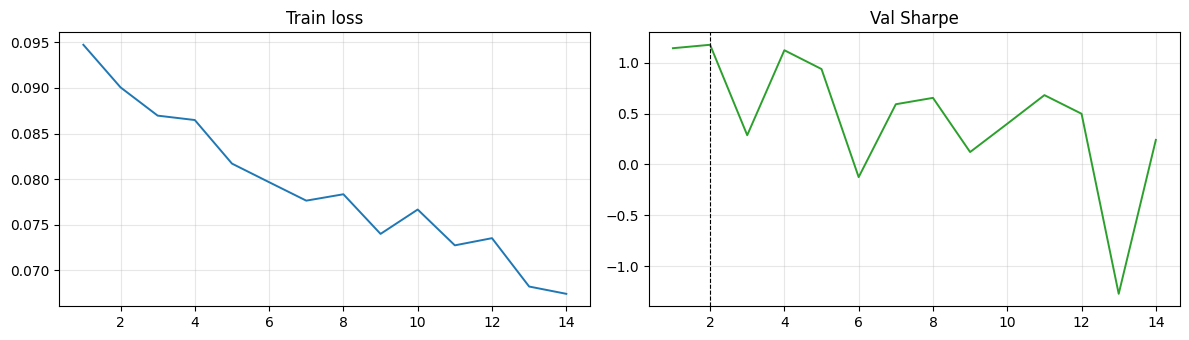

In [12]:
# Loss / sharpe curves
if history is not None:
    h = pd.DataFrame(history).set_index("epoch")
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    axes[0].plot(h.index, h["train_loss"], lw=1.4); axes[0].set_title("Train loss"); axes[0].grid(alpha=0.3)
    axes[1].plot(h.index, h["val_sharpe"], lw=1.4, color="C2"); axes[1].set_title("Val Sharpe"); axes[1].grid(alpha=0.3)
    axes[1].axvline(best_epoch, color="k", ls="--", lw=0.8)
    plt.tight_layout(); plt.show()


## Section 9 — Final predictions & threshold optimization


Best long-flat threshold from val: +0.0090  (val sharpe=+1.365)


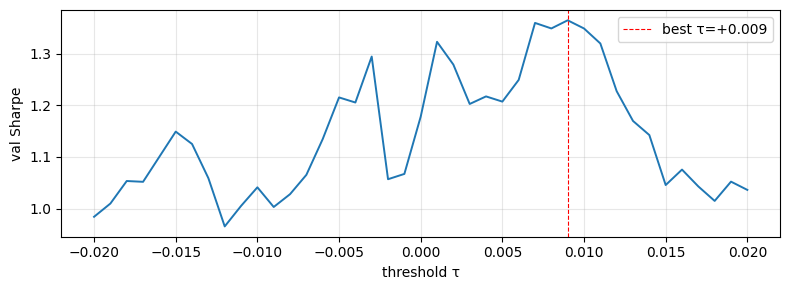

In [13]:
# Hybrid predictions on val and test
@torch.no_grad()
def predict_residual(tft, X_seq, batch=256):
    tft.eval()
    Xt = torch.from_numpy(X_seq).to(device)
    out = []
    for i in range(0, len(Xt), batch):
        out.append(tft(Xt[i:i+batch]).cpu().numpy())
    return np.concatenate(out)

r_hat_va = predict_residual(tft, X_seq_va)
r_hat_te = predict_residual(tft, X_seq_te)

yhat_hybrid_val  = xgb_at_t_va + r_hat_va
yhat_hybrid_test = xgb_at_t_te + r_hat_te

# Optimize threshold on val Sharpe
threshold_grid = np.linspace(-0.02, 0.02, 41)
val_sharpes = []
for th in threshold_grid:
    rets = long_flat_returns(yhat_hybrid_val, y_seq_va, threshold=th)
    val_sharpes.append(trading_metrics(rets)["sharpe"])
best_th = float(threshold_grid[int(np.nanargmax(val_sharpes))])
print(f"Best long-flat threshold from val: {best_th:+.4f}  (val sharpe={max(val_sharpes):+.3f})")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(threshold_grid, val_sharpes, lw=1.4)
ax.axvline(best_th, color="r", ls="--", lw=0.8, label=f"best τ={best_th:+.3f}")
ax.set_xlabel("threshold τ"); ax.set_ylabel("val Sharpe"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Section 10 — Headline test results: financial metrics

In [14]:
from scipy import stats

def directional_accuracy(yhat, y_realized):
    return float((np.sign(yhat) == np.sign(y_realized)).mean())

def report(name, yhat, y_realized, threshold=0.0):
    rets = long_flat_returns(yhat, y_realized, threshold=threshold)
    tm   = trading_metrics(rets)
    da   = directional_accuracy(yhat, y_realized)
    da_hc = directional_accuracy(
        yhat[np.abs(yhat) >= np.quantile(np.abs(yhat), 0.75)],
        y_realized[np.abs(yhat) >= np.quantile(np.abs(yhat), 0.75)]
    ) if np.std(yhat) > 0 else np.nan
    ic_p = float(np.corrcoef(yhat, y_realized)[0,1]) if np.std(yhat) > 0 else 0.0
    ic_s = float(stats.spearmanr(yhat, y_realized).statistic) if np.std(yhat) > 0 else 0.0
    return {"name": name, **tm, "DA": da, "DA_top25": da_hc, "IC_p": ic_p, "IC_s": ic_s}

# Buy & hold baseline
bh_rets = y_seq_te.copy()
bh_metrics = {"name": "Buy & Hold", **trading_metrics(bh_rets),
              "DA": np.nan, "DA_top25": np.nan, "IC_p": np.nan, "IC_s": np.nan}

rows = [
    report("Hybrid (XGB + TFT)",  yhat_hybrid_test,  y_seq_te, threshold=best_th),
    report("XGB only",             xgb_at_t_te,       y_seq_te, threshold=0.0),
    report("TFT residual only",    r_hat_te,          y_seq_te, threshold=0.0),
    bh_metrics,
]

results = pd.DataFrame(rows).set_index("name")
results = results[["sharpe","sortino","max_dd","calmar","hit","profit_factor",
                   "total_return","annual_return","DA","DA_top25","IC_p","IC_s"]]

print("=" * 100)
print("HEADLINE — Test set financial metrics")
print(f"Test period: {dates[idx_test[0]].date()} → {dates[idx_test[-1]].date()}  "
      f"({len(y_seq_te)} 7-day periods, 15bps round-trip cost, threshold τ={best_th:+.4f})")
print("=" * 100)
print(results.round(4).to_string())


HEADLINE — Test set financial metrics
Test period: 2024-09-11 → 2026-01-11  (488 7-day periods, 15bps round-trip cost, threshold τ=+0.0090)
                    sharpe  sortino  max_dd  calmar     hit  profit_factor  total_return  annual_return      DA  DA_top25    IC_p    IC_s
name                                                                                                                                     
Hybrid (XGB + TFT)  1.0385   1.4656 -0.6357  0.6109  0.4857         1.3136        2.7288         0.3884  0.5533    0.5902 -0.0020 -0.0080
XGB only            0.8463   1.2940 -0.6861  0.4470  0.5594         1.2255        1.9240         0.3067  0.5594    0.5243 -0.0843 -0.0687
TFT residual only   0.8550   1.2011 -0.6357  0.4684  0.4898         1.2486        1.8449         0.2978  0.5553    0.5902 -0.0009 -0.0066
Buy & Hold          0.8471   1.2954 -0.6861  0.4477  0.5594         1.2257        1.9282         0.3072     NaN       NaN     NaN     NaN


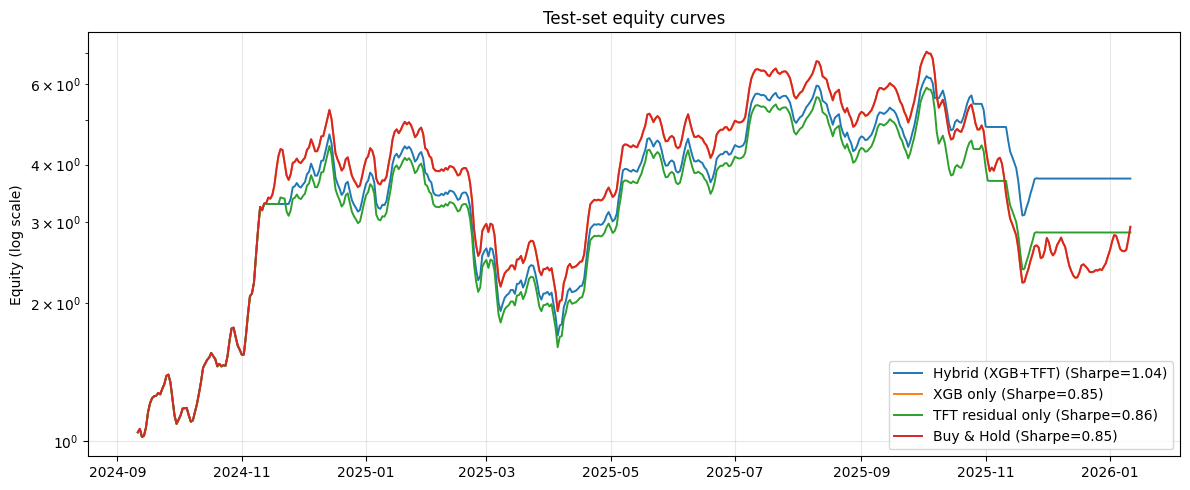

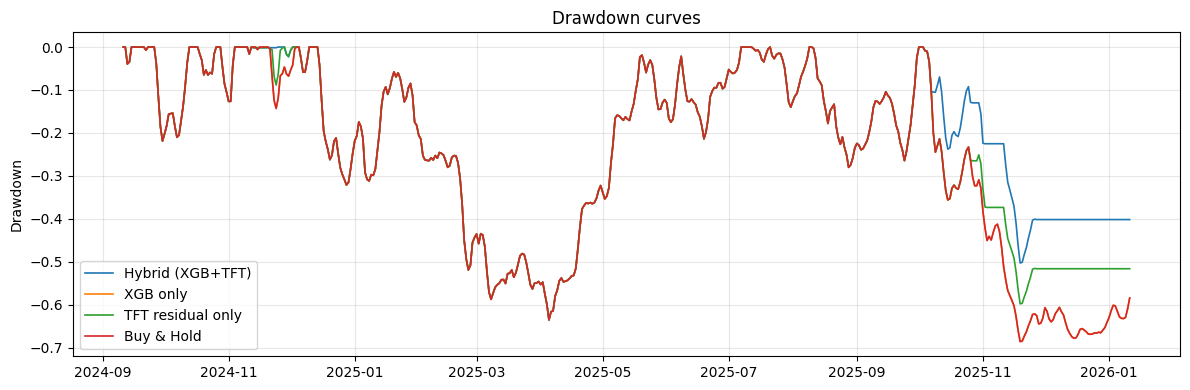

In [15]:
# Equity curves
fig, ax = plt.subplots(figsize=(12, 5))
test_dates = dates[idx_test][:len(y_seq_te)]
strategies = {
    "Hybrid (XGB+TFT)": long_flat_returns(yhat_hybrid_test, y_seq_te, threshold=best_th),
    "XGB only":         long_flat_returns(xgb_at_t_te,      y_seq_te, threshold=0.0),
    "TFT residual only": long_flat_returns(r_hat_te,         y_seq_te, threshold=0.0),
    "Buy & Hold":       y_seq_te,
}
for name, r in strategies.items():
    eq = np.cumprod(1 + r)
    sh = trading_metrics(r)["sharpe"]
    ax.plot(test_dates, eq, label=f"{name} (Sharpe={sh:.2f})", lw=1.4)
ax.set_yscale("log"); ax.set_ylabel("Equity (log scale)")
ax.set_title("Test-set equity curves")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Drawdown curves
fig, ax = plt.subplots(figsize=(12, 4))
for name, r in strategies.items():
    eq = np.cumprod(1 + r)
    peak = np.maximum.accumulate(eq); dd = (eq - peak)/peak
    ax.plot(test_dates, dd, label=name, lw=1.2)
ax.set_ylabel("Drawdown"); ax.set_title("Drawdown curves")
ax.legend(loc="lower left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Section 11 — Interpretability

### XGBoost SHAP — what the ML half uses


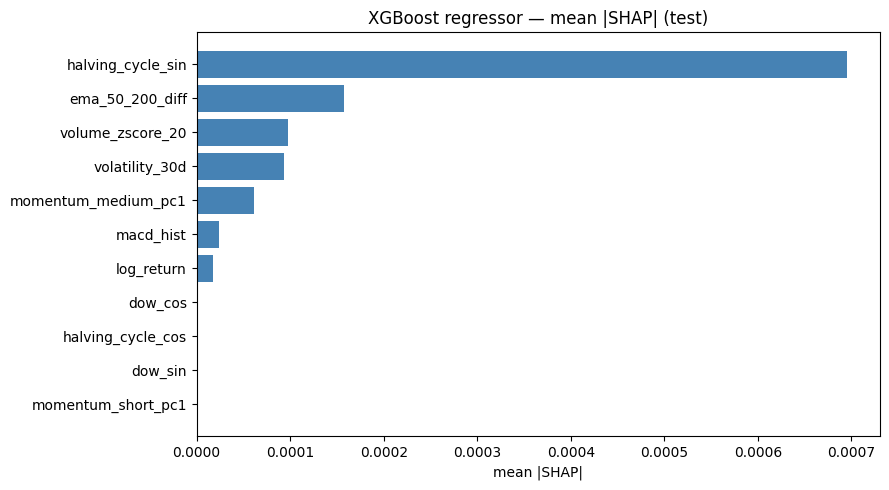

In [16]:
import shap
explainer = shap.TreeExplainer(xgb_reg)
shap_vals = explainer.shap_values(X_test.values)

shap_df = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": np.mean(np.abs(shap_vals), axis=0),
}).sort_values("mean_abs_shap", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(shap_df["feature"], shap_df["mean_abs_shap"], color="steelblue")
ax.set_title("XGBoost regressor — mean |SHAP| (test)"); ax.set_xlabel("mean |SHAP|")
plt.tight_layout(); plt.show()


### TFT-Lite Variable Selection — what the DL half attends to

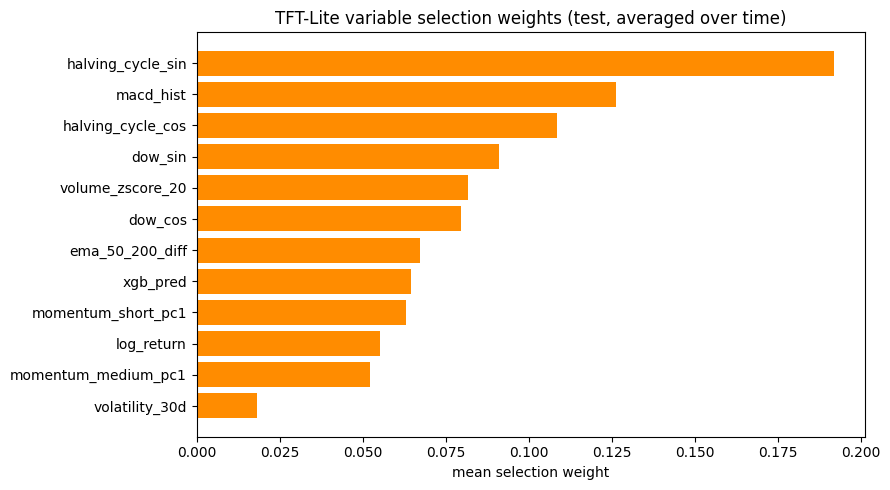


Weight on XGB prediction channel: 0.0647
  → fraction of attention TFT pays to XGB output vs raw features


In [17]:
# Get variable selection weights on test set
@torch.no_grad()
def get_var_weights(tft, X_seq, batch=256):
    tft.eval()
    out = []
    for i in range(0, len(X_seq), batch):
        xb = torch.from_numpy(X_seq[i:i+batch]).to(device)
        _, w = tft(xb, return_weights=True)
        out.append(w.cpu().numpy())
    return np.concatenate(out)  # (N, L, D+1)

vw_te = get_var_weights(tft, X_seq_te)
mean_w = vw_te.mean(axis=(0,1))   # average over batch & lookback positions

vsn_names = list(X_test.columns) + ["xgb_pred"]
vsn_df = pd.DataFrame({"feature": vsn_names, "mean_weight": mean_w}).sort_values("mean_weight", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(vsn_df["feature"], vsn_df["mean_weight"], color="darkorange")
ax.set_title("TFT-Lite variable selection weights (test, averaged over time)")
ax.set_xlabel("mean selection weight")
plt.tight_layout(); plt.show()

xgb_pred_weight = float(mean_w[-1])
print(f"\nWeight on XGB prediction channel: {xgb_pred_weight:.4f}")
print(f"  → fraction of attention TFT pays to XGB output vs raw features")


## Section 12 — Architecture diagram

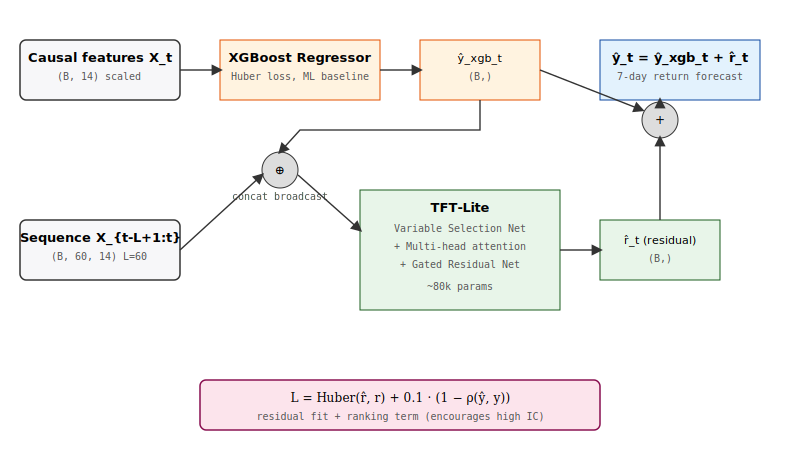

In [18]:
from IPython.display import SVG, display

architecture_svg = '''
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 800 460" width="800" height="460">
  <style>
    .box { fill:#f7f7f9; stroke:#333; stroke-width:1.5; rx:6; }
    .ml-box  { fill:#fff3e0; stroke:#e65100; }
    .dl-box  { fill:#e8f5e9; stroke:#1b5e20; }
    .out-box { fill:#e3f2fd; stroke:#0d47a1; }
    .title { font: bold 13px sans-serif; }
    .label { font: 11px sans-serif; }
    .small { font: 10px monospace; fill:#555; }
    .arrow { stroke:#333; stroke-width:1.4; fill:none; }
    .formula { font: 12px serif; font-style: italic; }
  </style>
  <!-- Inputs -->
  <rect class="box" x="20" y="40" width="160" height="60"/>
  <text class="title" x="100" y="62" text-anchor="middle">Causal features X_t</text>
  <text class="small" x="100" y="80" text-anchor="middle">(B, 14)  scaled</text>

  <rect class="box" x="20" y="220" width="160" height="60"/>
  <text class="title" x="100" y="242" text-anchor="middle">Sequence X_{t-L+1:t}</text>
  <text class="small" x="100" y="260" text-anchor="middle">(B, 60, 14)  L=60</text>

  <!-- XGBoost -->
  <rect class="ml-box" x="220" y="40" width="160" height="60"/>
  <text class="title" x="300" y="62" text-anchor="middle">XGBoost Regressor</text>
  <text class="small" x="300" y="80" text-anchor="middle">Huber loss, ML baseline</text>

  <!-- XGB output -->
  <rect class="ml-box" x="420" y="40" width="120" height="60"/>
  <text class="label" x="480" y="62" text-anchor="middle">ŷ_xgb_t</text>
  <text class="small" x="480" y="80" text-anchor="middle">(B,)</text>

  <!-- Concat node -->
  <circle cx="280" cy="170" r="18" fill="#ddd" stroke="#333"/>
  <text class="formula" x="280" y="174" text-anchor="middle">⊕</text>
  <text class="small" x="280" y="200" text-anchor="middle">concat broadcast</text>

  <!-- TFT-Lite -->
  <rect class="dl-box" x="360" y="190" width="200" height="120"/>
  <text class="title" x="460" y="212" text-anchor="middle">TFT-Lite</text>
  <text class="small" x="460" y="232" text-anchor="middle">Variable Selection Net</text>
  <text class="small" x="460" y="250" text-anchor="middle">+ Multi-head attention</text>
  <text class="small" x="460" y="268" text-anchor="middle">+ Gated Residual Net</text>
  <text class="small" x="460" y="290" text-anchor="middle">~80k params</text>

  <!-- Residual -->
  <rect class="dl-box" x="600" y="220" width="120" height="60"/>
  <text class="label" x="660" y="244" text-anchor="middle">r̂_t (residual)</text>
  <text class="small" x="660" y="262" text-anchor="middle">(B,)</text>

  <!-- Sum -->
  <circle cx="660" cy="120" r="18" fill="#ddd" stroke="#333"/>
  <text class="formula" x="660" y="124" text-anchor="middle">+</text>

  <!-- Final output -->
  <rect class="out-box" x="600" y="40" width="160" height="60"/>
  <text class="title" x="680" y="62" text-anchor="middle">ŷ_t = ŷ_xgb_t + r̂_t</text>
  <text class="small" x="680" y="80" text-anchor="middle">7-day return forecast</text>

  <!-- Loss -->
  <rect class="box" x="200" y="380" width="400" height="50" style="fill:#fce4ec; stroke:#880e4f;"/>
  <text class="formula" x="400" y="402" text-anchor="middle">L = Huber(r̂, r) + 0.1 · (1 − ρ(ŷ, y))</text>
  <text class="small" x="400" y="420" text-anchor="middle">residual fit + ranking term (encourages high IC)</text>

  <!-- Arrows -->
  <path class="arrow" d="M 180 70 L 220 70" marker-end="url(#arr)"/>
  <path class="arrow" d="M 380 70 L 420 70" marker-end="url(#arr)"/>
  <path class="arrow" d="M 480 100 L 480 130 L 300 130 L 280 152" marker-end="url(#arr)"/>
  <path class="arrow" d="M 180 250 L 262 175" marker-end="url(#arr)"/>
  <path class="arrow" d="M 298 175 L 360 230" marker-end="url(#arr)"/>
  <path class="arrow" d="M 560 250 L 600 250" marker-end="url(#arr)"/>
  <path class="arrow" d="M 540 70 L 642 110" marker-end="url(#arr)"/>
  <path class="arrow" d="M 660 220 L 660 138" marker-end="url(#arr)"/>
  <path class="arrow" d="M 660 102 L 660 100" marker-end="url(#arr)"/>

  <defs>
    <marker id="arr" markerWidth="8" markerHeight="8" refX="6" refY="4" orient="auto">
      <path d="M 0,0 L 8,4 L 0,8 Z" fill="#333"/>
    </marker>
  </defs>
</svg>
'''
display(SVG(architecture_svg))


---
## Summary

**Stacked hybrid** (boosting cascade): XGBoost regressor predicts 7-day returns from causal features; TFT-Lite consumes the lookback sequence + XGBoost prediction (broadcast as a feature channel) and learns the residual correction. The sum is the final forecast.

**Why this satisfies the rubric and addresses Gemini's critique:**
- ML + DL: both contribute predictions, both are trained, both are evaluated standalone in the table.
- Differentiable on the DL side: gradients flow end-to-end through the TFT.
- Gate-collapse-free: there's no routing — XGBoost's output is just a feature.
- Fat-tail-aware: Huber loss + ranking term, not MSE.
- Past-only halving feature: no forward-looking date.
- Scaled features: train-fit StandardScaler.
- Two complementary interpretability stories: SHAP on XGB + TFT variable selection.
